# Descriptor Generation and Analysis
#### The objective of this notebook is to generate descriptors, perform data preprocessing, and feature reduction. The complete workflow is provided below:

### |---------------Step-----------------:|-----------------Goal------------------| 

#### | Initial descriptor generation :-----------:|-RDKit descriptors for prediction modeling-|
#### | Descriptor inspection :------------------:|-Identifying & removing data quality issues-|
#### | Constant features removal :------------:|------Removing zero-variance features-------|
#### | Weakly correlated features removal:--:|---Removing noise-contributing features-----|
#### | Highly correlated features removal:---:|--------Removing feature redundancy---------|
#### | VIF Filtering (LR branch) :--------------:|----------Removing multicollinearity-----------|
#### | No VIF Filtering (ML branch) :---------:|----------Preserving predictive signal----------|

In [56]:
## Modules
import sys
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import numpy as np

## Sciki-learn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
import time
from sklearn.decomposition import PCA
import statsmodels.api as sm
from lazypredict.Supervised import LazyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.manifold import TSNE
from collections import Counter
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap

## RDKit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolsToGridImage 
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem import Descriptors
from rdkit.Chem.rdMolDescriptors import *
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys, AtomPairs, rdFingerprintGenerator
from rdkit.Chem import PandasTools
from rdkit import DataStructs
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors
from numpy import prod
from mordred import Calculator, descriptors
from rdkit.Chem import AddHs
from rdkit.Chem.rdmolops import PatternFingerprint
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.AtomPairs.Pairs import GetAtomPairFingerprintAsBitVect
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import warnings


In [2]:
data = pd.read_csv('delaney.csv')
data.head()

,Compound ID,SMILES,measured log(solubility:mol/L)
0,Acetamide,CC(=O)N,1.580
1,Methanol,CO,1.570
2,Methyl hydrazine,CNN,1.340
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144
4,Glycerol,OCC(O)CO,1.120


In [3]:
 # To create descriptors list, we are first creating an instance of the calculator class and since we want both 2D and 3D descriptors, using ignore_3D=False

mol_list = []

for smile in data['SMILES']:
    mol = Chem.MolFromSmiles(smile)           # generating molecule objects
    mol = Chem.AddHs(mol)                     # adding hydrogens
    AllChem.EmbedMolecule(mol)                # generating 3D geometries from these molecular objects
    mol_list.append(mol)                      


# adding a column of the newly generated molecular objects to our exisiting dataframe (data)
data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)    
data.head()


,Compound ID,SMILES,measured log(solubility:mol/L),Mol
0,Acetamide,CC(=O)N,1.580,<rdkit.Chem.rdchem.Mol object at 0x0000010F3D6...
1,Methanol,CO,1.570,<rdkit.Chem.rdchem.Mol object at 0x0000010F3D6...
2,Methyl hydrazine,CNN,1.340,<rdkit.Chem.rdchem.Mol object at 0x0000010F3D6...
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,<rdkit.Chem.rdchem.Mol object at 0x0000010F3D6...
4,Glycerol,OCC(O)CO,1.120,<rdkit.Chem.rdchem.Mol object at 0x0000010F3D6...


In [9]:
# generating a descriptor calculator

calc = Calculator(descriptors, ignore_3D=False)         # Use numpy==1.23.5 to avoid running into module errors
all_desc = calc.pandas(data['Mol'])                     # applying our descriptor calculator to the new 3D molecular objects
all_desc.head()

100%|██████████████████████████████████████████████████████████████████████████████| 1144/1144 [01:29<00:00, 12.75it/s]


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,2.449490,2.449490,0,0,3.464102,1.732051,3.464102,3.464102,0.866025,2.178059,...,6.188264,24.179697,59.037114,6.559679,9,0,12.0,9.0,3.111111,1.000000
1,0.000000,0.000000,0,0,2.000000,1.000000,2.000000,2.000000,1.000000,1.407606,...,1.098612,7.493061,32.026215,5.337702,1,0,2.0,1.0,2.0,1.000000
2,1.414214,1.414214,0,0,2.828427,1.414214,2.828427,2.828427,0.942809,1.849457,...,4.174387,17.310771,46.053098,5.117011,4,0,6.0,4.0,2.25,1.000000
3,10.943860,10.834541,0,0,19.178732,2.222674,4.445348,19.178732,1.198671,3.613477,...,9.152817,46.989352,287.041487,8.442397,532,20,68.0,73.0,8.034722,3.986111
4,3.644924,4.097495,0,0,6.898979,1.931852,3.863703,6.898979,1.149830,2.595800,...,7.280008,29.753427,92.047344,6.574810,31,4,20.0,19.0,3.611111,1.666667


## Feature Retention Summary
#### | Step:------------------------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :---------:|...............<span style="color:blue;">1826</span>...............|

In [10]:
# Combining all the descriptors with our dataset 
calc = Calculator(descriptors, ignore_3D=False)
all_desc = calc.pandas(data['Mol']) 
df_index = data[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']]
df = pd.concat([df_index, all_desc], axis=1)

df.to_excel('delaney_mordred.xlsx', index=None)
df.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,Acetamide,CC(=O)N,1.580,2.449490,2.449490,0,0,3.464102,1.732051,3.464102,...,6.188264,24.179697,59.037114,6.559679,9,0,12.0,9.0,3.111111,1.000000
1,Methanol,CO,1.570,0.000000,0.000000,0,0,2.000000,1.000000,2.000000,...,1.098612,7.493061,32.026215,5.337702,1,0,2.0,1.0,2.0,1.000000
2,Methyl hydrazine,CNN,1.340,1.414214,1.414214,0,0,2.828427,1.414214,2.828427,...,4.174387,17.310771,46.053098,5.117011,4,0,6.0,4.0,2.25,1.000000
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,10.943860,10.834541,0,0,19.178732,2.222674,4.445348,...,9.152817,46.989352,287.041487,8.442397,532,20,68.0,73.0,8.034722,3.986111
4,Glycerol,OCC(O)CO,1.120,3.644924,4.097495,0,0,6.898979,1.931852,3.863703,...,7.280008,29.753427,92.047344,6.574810,31,4,20.0,19.0,3.611111,1.666667


## Descriptor Inspection
- Examine descriptor types, dimensions, and missing values to verify that descriptor generation was successful and identify potential data quality issues

In [12]:
# Missing Values: Let's check if any null value exists

data = df.iloc[:, 3:]           # Before making any changes, let's save a new dataset with name 'data' we're grabbing all the columns including and after column 3


# Removing missing values
data.isnull().sum().sum()    

0

In [13]:
# Let's look for non-numeric values/strings/errors

column_num = []              # list of columns with only numeric values
column_bool = []             # list of columns with only non-numeric (boolean) values

# Let's screen for the data type of each column to differentiate between the numerical columns and the rest

for column in data.columns:
  column_type = data[column].dtype
  if column_type == 'object':
      pass
  elif column_type =='bool':
      column_bool.append(column)
  else:
      column_num.append(column)

column_bool

['Lipinski', 'GhoseFilter']

In [18]:
ghoseFilter.value_counts()
lipsinki.value_counts()

Lipinski
1    1030
0     114
Name: count, dtype: int64

<Axes: xlabel='GhoseFilter'>

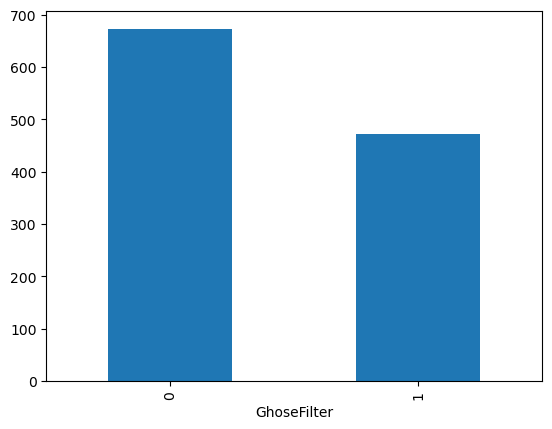

In [16]:
# Let's convert these TRUE and FALSE values into 0 and 1
#lipsinki = data['Lipinski'].astype(int)
#lipsinki.value_counts().plot(kind='bar')
# Lipinski: TRUE = 1030, TRUE = FALSE
ghoseFilter = data['GhoseFilter'].astype(int)
ghoseFilter.value_counts().plot(kind='bar')
# GhoseFilter: False = 673, TRUE = 471

## Descriptor (boolean) analysis:
-  There are 2 boolean columns in the dataset ['Lipinski', 'GhoseFilter'] which make sense as both these columns correpond to a molecule meeting or not meeting a predefined critirea of physicochemical properties to determine DRUG-Likeness. 
- DRUG-LIKE SPACE: These molecules have around 30 heavy atoms and have a M.W. within 400-450 depending on the identity of the 30 atoms.
- LIPINSKI’s Rule of 5: this is a criteria for orally available drugs. oral drugs should have a M.W. ≤ 500 g/mol, hydrogen bond donors ≤ 5, hydrogen bond acceptors ≤ 10, logP (measure of lipophilicity) ≤ 5. A compound that breaks 2 or more of these rules is at high risk of having poor oral availability. But it is more of a guideline than a strict requirement as there are several successful drugs that don't meet this critirea. (C. A. Lipinski, F. Lombardo, B. W. Dominy and P. J. Feeney, Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings, Advanced Drug Delivery Reviews, 1997, 23, 3-25.)
- GHOSE Filter: Another critirea to check empirical drug-likeness of a molecule. oral drugs should have a M.W. 160-480 g/mol, molar refractivity (MR): 40-130, number of atoms: 20-70, logP (measure of lipophilicity): -0.4 to 5.6. Several acceptable drug-like molecules fail Ghose because of being too small, too large, too simple, or outside the atom count range. (A. K. Ghose, V. N. Viswanadhan and J. J. Wendoloski, A Knowledge-Based Approach in Designing Combinatorial or Medicinal Chemistry Libraries for Drug Discovery. 1. A Qualitative and Quantitative Characterization of Known Drug Databases, Journal of Combinatorial Chemistry, 1999, 1, 55-68)
- Approximately 90% of compounds satisfied Lipinski's Rule of Five highlighting that the majority of the molecules in the dataset occupy drug-like chemical space. Furthermore, our mean value of aqueous solubiltiy (logS) was around -3, which correlates with high Lipinski pass rate.
- However, only 41% of compounds satisfied the Ghose filter which reflect the narrower physicochemical ranges imposed by this criterion. This indicates that there is still a substantial structural diversity in the dataset.
- Altogether, these observations indicate that our dataset is largely representative of the drug-like molecules from medicinal chemistry and also retain enough diversity in structural and physicochemical properties to allow for efficient modeling.

In [19]:
data = data[column_num + column_bool]
data.head()

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
0,2.449490,2.449490,0,0,3.464102,1.732051,3.464102,3.464102,0.866025,2.178059,...,24.179697,59.037114,6.559679,9,0,12.0,9.0,1.000000,True,False
1,0.000000,0.000000,0,0,2.000000,1.000000,2.000000,2.000000,1.000000,1.407606,...,7.493061,32.026215,5.337702,1,0,2.0,1.0,1.000000,True,False
2,1.414214,1.414214,0,0,2.828427,1.414214,2.828427,2.828427,0.942809,1.849457,...,17.310771,46.053098,5.117011,4,0,6.0,4.0,1.000000,True,False
3,10.943860,10.834541,0,0,19.178732,2.222674,4.445348,19.178732,1.198671,3.613477,...,46.989352,287.041487,8.442397,532,20,68.0,73.0,3.986111,True,True
4,3.644924,4.097495,0,0,6.898979,1.931852,3.863703,6.898979,1.149830,2.595800,...,29.753427,92.047344,6.574810,31,4,20.0,19.0,1.666667,True,False


In [21]:
# Let's add back out targets from the original dataset

data = pd.concat(
    [df[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']],
     data
    ], axis=1
)
data.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
0,Acetamide,CC(=O)N,1.580,2.449490,2.449490,0,0,3.464102,1.732051,3.464102,...,24.179697,59.037114,6.559679,9,0,12.0,9.0,1.000000,True,False
1,Methanol,CO,1.570,0.000000,0.000000,0,0,2.000000,1.000000,2.000000,...,7.493061,32.026215,5.337702,1,0,2.0,1.0,1.000000,True,False
2,Methyl hydrazine,CNN,1.340,1.414214,1.414214,0,0,2.828427,1.414214,2.828427,...,17.310771,46.053098,5.117011,4,0,6.0,4.0,1.000000,True,False
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,10.943860,10.834541,0,0,19.178732,2.222674,4.445348,...,46.989352,287.041487,8.442397,532,20,68.0,73.0,3.986111,True,True
4,Glycerol,OCC(O)CO,1.120,3.644924,4.097495,0,0,6.898979,1.931852,3.863703,...,29.753427,92.047344,6.574810,31,4,20.0,19.0,1.666667,True,False


In [79]:
drop_cols = ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
print(df.drop(columns=drop_cols).shape)
print(data.drop(columns=drop_cols).shape)

(1144, 1826)
(1144, 1273)


## Feature Retention Summary
#### | Step:------------------------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :---------:|...............<span style="color:blue;">1826</span>...............|
#### | Descriptor inspection :----------------:|................<span style="color:blue;">1273</span>...............|

## Removing constant features
- Remove descriptors with only one unique value as constant descriptors contain no information and cannot contribute to prediction

In [23]:
# Removing constant values

def remove_constant_values(data):
    return [e for e in data.columns[3:] if data[e].nunique() == 1] 
    
drop_col = remove_constant_values(data)

new_df_columns = [e for e in data.columns if e not in drop_col] 

new_df = data[new_df_columns]
new_df

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,ABCGG,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
0,Acetamide,CC(=O)N,1.580,2.449490,2.449490,0,3.464102,1.732051,3.464102,3.464102,...,24.179697,59.037114,6.559679,9,0,12.0,9.0,1.000000,True,False
1,Methanol,CO,1.570,0.000000,0.000000,0,2.000000,1.000000,2.000000,2.000000,...,7.493061,32.026215,5.337702,1,0,2.0,1.0,1.000000,True,False
2,Methyl hydrazine,CNN,1.340,1.414214,1.414214,0,2.828427,1.414214,2.828427,2.828427,...,17.310771,46.053098,5.117011,4,0,6.0,4.0,1.000000,True,False
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,10.943860,10.834541,0,19.178732,2.222674,4.445348,19.178732,...,46.989352,287.041487,8.442397,532,20,68.0,73.0,3.986111,True,True
4,Glycerol,OCC(O)CO,1.120,3.644924,4.097495,0,6.898979,1.931852,3.863703,6.898979,...,29.753427,92.047344,6.574810,31,4,20.0,19.0,1.666667,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,-9.018,18.687482,12.675910,0,31.425065,2.638574,5.277147,31.425065,...,57.909470,276.093900,8.120409,815,49,138.0,178.0,4.527778,False,False
1140,"2,2',3,3',5,5',6,6'-PCB",Clc1cc(Cl)c(Cl)c(c1Cl)c2c(Cl)c(Cl)cc(Cl)c2Cl,-9.150,15.360400,14.089668,0,24.388882,2.500877,5.001754,24.388882,...,54.195708,425.766472,19.353021,702,38,106.0,129.0,4.333333,False,False
1141,"2,2',3,3',4,4',5,5'-PCB",Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl,-9.160,15.360400,13.873764,0,24.949868,2.478081,4.956161,24.949868,...,54.168494,425.766472,19.353021,738,38,106.0,129.0,4.333333,False,False
1142,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,20.727922,13.352493,0,34.571837,2.675131,5.350262,34.571837,...,60.626753,300.093900,8.335942,1002,57,156.0,204.0,4.833333,False,False


In [80]:
drop_cols = ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
print(data.drop(columns=drop_cols).shape)
print(new_df.drop(columns=drop_cols).shape)

(1144, 1273)
(1144, 1120)


## Feature Retention Summary
#### | Step:------------------------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :---------:|...............<span style="color:blue;">1826</span>...............|
#### | Descriptor inspection :----------------:|................<span style="color:blue;">1273</span>...............|
#### | Constant features removed :----------:|............... <span style="color:blue;">1120</span>..............|


# External Validation Split
- To ensure that both the development and external validation sets contained compounds spanning the full experimental solubility range, molecules were stratified (80:20 split) according to binned logS values prior to splitting
- This would prevent over/under-representation of highly soluble or poorly soluble compounds in either of the subsets

In [95]:
# Creating a new clean dataset with all the data preprocessed
new_df.to_csv("full_dataset_1120_descriptors.csv", index=False)


# Creating solubility bins to divide the data based on solubility values
new_df["logS_bin"] = pd.qcut(
    new_df["measured log(solubility:mol/L)"],
    q=5,
    labels=False
)

# Stratified split
development_df, external_df = train_test_split(
    new_df,
    test_size=0.20,
    stratify=new_df["logS_bin"],
    random_state=42
)

# Removing temporary bin column
development_df = development_df.drop(columns=["logS_bin"])
external_df = external_df.drop(columns=["logS_bin"])

print(development_df.shape)
print(external_df.shape)

development_df.to_csv("development_set.csv", index=False)
external_df.to_csv("external_validation_set.csv", index=False)

C:\Users\Rajwinder\AppData\Local\Temp\ipykernel_44160\3007881217.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["logS_bin"] = pd.qcut(


(915, 1123)
(229, 1123)


In [96]:
print(
    development_df['measured log(solubility:mol/L)'].describe()
)

print(
    external_df['measured log(solubility:mol/L)'].describe()
)

count    915.000000
mean      -3.036420
std        2.087335
min      -11.600000
25%       -4.310000
50%       -2.850000
75%       -1.600000
max        1.580000
Name: measured log(solubility:mol/L), dtype: float64
count    229.000000
mean      -3.144214
std        2.135184
min       -9.160000
25%       -4.420000
50%       -3.030000
75%       -1.620000
max        1.144000
Name: measured log(solubility:mol/L), dtype: float64


# Result
- The data was successfully split to extract an external validation set
- Similar values of mean, std, median show that stratification worked and that both subsets contain a comparable range of solubility values

## Descriptor–Target Correlation Analysis
- Calculate correlation between each descriptor and the target variable (solubility, logS) to identify descriptors that show evidence of correlation with the target property

In [97]:
development_df

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,ABCGG,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
144,p-Cresol,Cc1ccc(O)cc1,-0.730,5.875634,5.525875,0,9.924777,2.170086,4.340173,9.924777,...,35.730685,108.057515,6.753595,62,7,36.0,38.0,1.833333,True,False
14,tetramethylurea,CN(C)C(=O)N(C)C,0.940,5.415816,5.894012,0,8.424292,2.135779,4.271558,8.424292,...,35.071670,116.094963,5.804748,65,8,32.0,33.0,1.888889,True,False
420,metharbital,CCC1(CC)C(=O)NC(=O)N(C)C1=O,-2.230,10.132955,10.244418,0,16.693897,2.484372,4.968743,16.693897,...,46.349371,198.100442,7.075016,264,27,70.0,86.0,3.305556,True,True
281,"1,2-Dichloropropane",CC(Cl)CCl,-1.600,3.047207,3.305183,0,5.226252,1.847759,3.695518,5.226252,...,27.254130,111.984656,10.180423,18,2,16.0,14.0,1.333333,True,False
520,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-2.620,14.784941,12.592540,0,25.175643,2.497680,4.872484,25.175643,...,61.070421,254.116761,7.700508,587,38,102.0,125.0,4.277778,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Dyphylline,Cn2c(=O)n(C)c1ncn(CC(O)CO)c1c2=O,-0.170,13.698897,12.786594,0,22.664679,2.517017,4.952388,22.664679,...,65.430128,254.101505,7.940672,568,31,94.0,114.0,4.027778,True,False
250,Butyl acetate,CCCCOC=O,-1.370,4.242641,4.530950,0,8.054679,1.847759,3.695518,8.054679,...,30.257210,102.068080,6.004005,56,4,22.0,20.0,2.000000,True,False
717,"Etoposide (148-167,25mg/ml)",COc1cc(cc(OC)c1O)C6C2C(COC2=O)C(OC4OC3COC(C)OC...,-3.571,33.881473,25.783550,0,55.767368,2.606869,5.168754,55.767368,...,96.137909,588.184291,7.948436,5464,83,242.0,302.0,9.000000,False,False
772,Hexane,CCCCCC,-3.840,3.535534,3.869735,0,6.987918,1.801938,3.603875,6.987918,...,28.105124,86.109550,4.305478,35,3,18.0,16.0,1.750000,True,False


In [98]:
# Let's check which descriptors are the least informative for predicting solubility? Does this feature help prediction?

corr_target = development_df.corr(numeric_only=True)['measured log(solubility:mol/L)']

corr_target = corr_target.drop('measured log(solubility:mol/L)')

# Creating a list of the descriptor names that fail to meet the threshold of 0.1 for correlation coefficients

weak_features = corr_target[abs(corr_target) < 0.1].index
print("Number of weakly correlated descriptors:", len(weak_features))


Number of weakly correlated descriptors: 312


In [101]:
# Creating a new dataset that has all descriptors with |r| ≥ 0.1

filtered_df = development_df.drop(columns=weak_features)

drop_cols = ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
print("Original shape:", development_df.drop(columns=drop_cols).shape)
print("Filtered shape:", filtered_df.drop(columns=drop_cols).shape)

filtered_df.to_csv("filtered_dataset_weak_corr_removed.csv", index=False)

Original shape: (915, 1120)
Filtered shape: (915, 808)


In [100]:
remaining_corr = corr_target[abs(corr_target) >= 0.1]

remaining_corr.sort_values(key=abs).head(10)

ATSC5dv        0.101207
ETA_shape_x   -0.102001
NsssN         -0.102353
C1SP2          0.102797
JGI2          -0.103004
SMR_VSA3       0.103793
NdS           -0.104663
SlogP_VSA2     0.105234
nG12FAHRing   -0.105330
Mor14p         0.106883
Name: measured log(solubility:mol/L), dtype: float64

## Result
- There are 312 descriptors that are weakly correlated with solubility, indicating little linear association with solubility
- Descriptors exhibiting an absolute Pearson correlation coefficient below 0.1 were removed to reduce the number of features and simplify the descriptor set.
- The threshold cut-off was kept low because Pearson correlation captures only linear relationships, and there might be some features that look too weakly correlated, but they might still contribute to non-linear machine learning models. Therefore, subsequent feature importance and SHAP analyses were performed to get a clearer picture of the descriptors contributing to predictive performance 

## Feature Retention Summary
#### | Step:------------------------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :---------:|...............<span style="color:blue;">1826</span>...............|
#### | Descriptor inspection :----------------:|................<span style="color:blue;">1273</span>...............|
#### | Constant features removed :----------:|............... <span style="color:blue;">1120</span>..............|
#### | Weakly correlated features (to the
####  target variable) removed  :--------------:|................<span style="color:blue;">808</span>................|

## Inter-Descriptor Correlation Analysis
- Identify redundancy among descriptors to determine whether multiple descriptors are describing similar physicochemical properties
- Remove these highly correlated features

In [102]:
# Making a dataset containing only descriptors

descriptor_df = filtered_df.drop(
    columns=['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
)


# Calculating Pearson correlation coefficiencts for each inter-descriptor pair

corr_matrix = descriptor_df.corr().abs()

# Keeping only the upper part of correlation matrix to avoid redundancy

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


# Calculating the total number of descriptor-descriptor pairs that meet the threshold of 0.85

n_pairs = (upper > 0.85).sum().sum()

print("Number of descriptor pairs with |r| > 0.85:", n_pairs)

# Checking if each of these descescriptor columns contain at least one correlation above 0.85.
# If the critirea is met, that descriptor column is marked for removal

highly_correlated_features = [column for column in upper.columns
                              if any(upper[column] > 0.85)
                             ]
print("Number of highly correlated features:", len(highly_correlated_features))


# Removing highly correlated feature columns from our dataset
filtered_df2 = filtered_df.drop(columns=highly_correlated_features)

drop_cols = ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
print("Original shape:", filtered_df.drop(columns=drop_cols).shape)
print("Filtered shape:", filtered_df2.drop(columns=drop_cols).shape)

filtered_df2.to_csv("filtered_dataset_high_corr_removed.csv", index=False)

Number of descriptor pairs with |r| > 0.85: 24441
Number of highly correlated features: 590
Original shape: (915, 808)
Filtered shape: (915, 218)


In [62]:
filtered_df2 

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,SpMax_A,SpMAD_A,nAromAtom,nHetero,nF,nCl,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,Acetamide,CC(=O)N,1.580,2.449490,1.732051,0.866025,0,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,True,False
1,Methanol,CO,1.570,0.000000,1.000000,1.000000,0,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,True,False
2,Methyl hydrazine,CNN,1.340,1.414214,1.414214,0.942809,0,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,True,False
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,10.943860,2.222674,1.198671,0,8,0,0,...,0.043750,0.028571,0.020202,0.024490,0.022727,0.011223,0.005714,0.0,True,True
4,Glycerol,OCC(O)CO,1.120,3.644924,1.931852,1.149830,0,3,0,0,...,0.031250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,-9.018,18.687482,2.638574,1.428412,22,0,0,0,...,0.033163,0.047536,0.019895,0.010909,0.000000,0.000000,0.000000,0.0,False,False
1140,"2,2',3,3',5,5',6,6'-PCB",Clc1cc(Cl)c(Cl)c(c1Cl)c2c(Cl)c(Cl)cc(Cl)c2Cl,-9.150,15.360400,2.500877,1.219444,12,8,0,8,...,0.062500,0.065621,0.028646,0.020408,0.012346,0.000000,0.000000,0.0,False,False
1141,"2,2',3,3',4,4',5,5'-PCB",Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl,-9.160,15.360400,2.478081,1.247493,12,8,0,8,...,0.059211,0.066370,0.034444,0.029462,0.019907,0.010918,0.000000,0.0,False,False
1142,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,20.727922,2.675131,1.440493,24,0,0,0,...,0.026316,0.048395,0.022222,0.008163,0.000000,0.000000,0.000000,0.0,False,False


## Result
- 24441 descriptor pairs were found to be too highly correated to each other with correlation cofficients > 0.85
- 590 highly correlated descriptors were identified and removed from the dataset, the number of features reducing from 808 to 218
- Since several descriptors were found to be strongly correlated with each other, this indicates that they describe similar molecular properties
- Keeping these descriptors will increase model complexity without gaining any substantial new information; therefore, these highly correlated descriptors were dropped from the dataset to reduce redundancy 

## Feature Retention Summary
#### | Step:------------------------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :---------:|...............<span style="color:blue;">1826</span>...............|
#### | Descriptor inspection :----------------:|................<span style="color:blue;">1273</span>...............|
#### | Constant features removed :----------:|............... <span style="color:blue;">1120</span>..............|
#### | Weakly correlated features (to the
####  target variable) removed  :--------------:|................<span style="color:blue;">797</span>................|
#### | Highly correlated (inter-descriptor)
####   features removed:----------------------: |................<span style="color:blue;">218</span>................|

## Variance Inflation Factor (VIF) analysis
- Identify remaining multicollinearity to detect redundant linear dependencies among descriptors that might not have been completely removed after pairwise correlation filtering
- Although correlation analysis measures the correlation between 2 descriptors (Descriptor A vs Descriptor B), it does not take into account if one of the features is strong enough to provide description when other multiple descriptors are combined (Descriptor A vs (Descriptor C + Descriptor E + DescriptorF)), this shows that there is still redundancy present in the dataset; therefore , VIF analysis is performed.

In [108]:
filtered_df2 

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,SpMax_A,SpMAD_A,nAromAtom,nBridgehead,nHetero,nF,...,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,SRW05,Lipinski,GhoseFilter
144,p-Cresol,Cc1ccc(O)cc1,-0.730,5.875634,2.170086,1.240597,6,0,1,0,...,0.151111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
14,tetramethylurea,CN(C)C(=O)N(C)C,0.940,5.415816,2.135779,1.053037,0,0,3,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
420,metharbital,CCC1(CC)C(=O)NC(=O)N(C)C1=O,-2.230,10.132955,2.484372,1.192421,0,0,5,0,...,0.057333,0.033730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,True
281,"1,2-Dichloropropane",CC(Cl)CCl,-1.600,3.047207,1.847759,1.045250,0,0,2,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
520,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-2.620,14.784941,2.497680,1.325034,12,0,5,0,...,0.048634,0.025517,0.017589,0.004913,0.000000,0.000000,0.000000,0.000000,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Dyphylline,Cn2c(=O)n(C)c1ncn(CC(O)CO)c1c2=O,-0.170,13.698897,2.517017,1.259149,9,0,8,0,...,0.060432,0.036213,0.029328,0.019618,0.009020,0.000000,0.000000,2.397895,True,False
250,Butyl acetate,CCCCOC=O,-1.370,4.242641,1.847759,1.150668,0,0,2,0,...,0.026667,0.027778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
717,"Etoposide (148-167,25mg/ml)",COc1cc(cc(OC)c1O)C6C2C(COC2=O)C(OC4OC3COC(C)OC...,-3.571,33.881473,2.606869,1.327794,12,0,13,0,...,0.048608,0.023870,0.020416,0.016130,0.011796,0.010242,0.007965,3.044522,False,False
772,Hexane,CCCCCC,-3.840,3.535534,1.801938,1.164653,0,0,0,0,...,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False


In [103]:
# Keeping only the descriptor columnns from the dataset
descriptor_df2 = filtered_df2.drop(columns=['Compound ID', 'SMILES', 'measured log(solubility:mol/L)'])
descriptor_df2 = descriptor_df2.astype(float)
# Creating an empty table with just the descriptor names in which we can fill the VIF values later

vif_data = pd.DataFrame()
vif_data["Descriptor"] = descriptor_df2.columns

# Making a for loop to get indices for all the columns and then matching those indices with descriptors and then calculating VIF on these descriptors

vif_data["VIF"] = [
    variance_inflation_factor(descriptor_df2.values, i)
    for i in range(len(descriptor_df2.columns))
]
vif_data["VIF"]

vif_data.sort_values(by="VIF", ascending=False).head(20)
high_vif = vif_data[vif_data["VIF"] > 10]
print("Descriptors with VIF > 10:", len(high_vif))

C:\Users\Rajwinder\miniconda3\envs\myenvironment\lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Rajwinder\miniconda3\envs\myenvironment\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Descriptors with VIF > 10: 198


In [104]:
# Calculating the descriptors with high VIF values > 10
high_vif = vif_data[vif_data["VIF"] > 10]
print("Descriptors with VIF > 10:", len(high_vif))

drop_cols = ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']
print("Initial descriptor:", filtered_df2.drop(columns=drop_cols).shape)
print("After VIF filtering:", len(vif_data))

Descriptors with VIF > 10: 198
Initial descriptor: (915, 218)
After VIF filtering: 218


In [115]:
# Saving the pre-VIF to .csv file for ML branch modeling and after-VIF filtering to .csv file for LR modeling

# Getting the names of descriptors to keep
keep_descriptors = vif_data.loc[
    vif_data["VIF"] <= 10,
    "Descriptor"
].tolist()

# Keep the 3 original columns + retained descriptors
final_df = filtered_df2[
    ['Compound ID', 'SMILES', 'measured log(solubility:mol/L)'] +
    keep_descriptors
]

# Save to CSV

filtered_df2.to_csv("04_filtered_dataset_high_corr_removed_before_VIF.csv", index=False)
final_df.to_csv("05_filtered_dataset_after_VIF_filtering.csv", index=False)

final_df

,Compound ID,SMILES,measured log(solubility:mol/L),ATSC6d,ATSC5Z,ATSC6Z,ATSC8Z,ATSC8se,ATSC5i,RPCS,...,Mor24v,SMR_VSA9,nG12FHRing,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,GhoseFilter
144,p-Cresol,Cc1ccc(O)cc1,-0.730,1.000000,54.359375,-40.687500,0.000000,0.000000,3.688078,67.213656,...,0.016480,5.749512,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
14,tetramethylurea,CN(C)C(=O)N(C)C,0.940,3.240000,-147.840000,174.240000,0.000000,0.000000,-21.733826,25.923651,...,0.192298,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
420,metharbital,CCC1(CC)C(=O)NC(=O)N(C)C1=O,-2.230,7.500000,-219.224490,34.979592,0.000000,0.000000,7.563862,29.238695,...,0.077340,0.000000,0,0.033730,0.000000,0.000000,0.000000,0.000000,0.000000,True
281,"1,2-Dichloropropane",CC(Cl)CCl,-1.600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.661939,...,-0.111459,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
520,Reverse Transcriptase inhibitor 1,CCN2c1ncccc1N(C)C(=O)c3cccnc23,-2.620,-6.918274,-247.332415,-234.491276,179.833792,0.685359,0.089624,50.187139,...,0.164771,0.000000,1,0.025517,0.017589,0.004913,0.000000,0.000000,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Dyphylline,Cn2c(=O)n(C)c1ncn(CC(O)CO)c1c2=O,-0.170,-5.593750,-164.804688,-36.492188,-98.671875,-0.722226,-10.582389,67.733890,...,-0.138083,0.000000,0,0.036213,0.029328,0.019618,0.009020,0.000000,0.000000,False
250,Butyl acetate,CCCCOC=O,-1.370,-0.103806,-10.442907,-23.162630,0.000000,0.000000,4.342049,73.076255,...,0.018970,0.000000,0,0.027778,0.000000,0.000000,0.000000,0.000000,0.000000,False
717,"Etoposide (148-167,25mg/ml)",COc1cc(cc(OC)c1O)C6C2C(COC2=O)C(OC4OC3COC(C)OC...,-3.571,-1.843682,64.084003,-124.728269,36.460190,3.261130,7.904595,91.647822,...,0.209698,28.747559,1,0.023870,0.020416,0.016130,0.011796,0.010242,0.007965,False
772,Hexane,CCCCCC,-3.840,0.720000,-4.250000,-4.500000,0.000000,0.000000,-0.929375,129.876158,...,-0.045775,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False


## Results
- 6 descriptors had a VIF of inf which indicates that these descriptors can be perfectly predicted from other descriptors
- Several descriptors had signficantly high VIF values suggesting that these descriptors are nearly perfectly redundant combinations of other descriptors, hence they give no additional information that is already not provided by other descriptors
- Altogether, this shows the dataset has severe multicollinearity issues highlighting why VIF is still needed after the pairwise correlation analysis 
- We began with 218 descriptors in our dataset, but VIF shows that ~90% are strongly interdependent, which leaves only a small portion of descriptors that are independent for subsequent modeling 
- However, these features were not removed from the datset since VIF does not measure predictive usefulness, only linear dependence.
- Removing the features just based on linear dependence may lead to dropping of descriptors that might be chemically meaningful or descriptors that might be useful in nonlinear machine learning models such as Random Forest and XGBoost

## Feature Retention Summary
### |:--------------Step-----------------:|-----------------Goal------------------:| <span style="color:blue;">Features Remaining</span>|

#### | Initial descriptor generation :-----------:|-RDKit descriptors for prediction modeling-|<span style="color:blue;">-----------1826-----------</span>|
#### | Descriptor inspection :------------------:|-Identifying & removing data quality issues-|<span style="color:blue;">-----------1273-----------</span>|
#### | Constant features removal :------------:|------Removing zero-variance features-------|<span style="color:blue;">-----------1120-----------</span>|
#### | Weakly correlated features removal:--:|---Removing noise-contributing features-----| <span style="color:blue;">-----------800-----------</span>|
#### | Highly correlated features removal:---:|--------Removing feature redundancy---------|<span style="color:blue;">-----------218------------</span>|
#### | VIF Filtering (LR branch) :--------------:|----------Removing multicollinearity-----------|<span style="color:blue;">-----------18-------------</span>|
#### | No VIF Filtering (ML branch) :---------:|----------Preserving predictive signal----------|<span style="color:blue;">-----------218------------</span>|
